# Детекция аномалий сетевого трафика

## 0. Импорт модулей 

In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from modules.parser import parse_srx_syslog, compute_session_duration, debug_line
from modules.parser import parse_srx_syslog as parse_srx_logs
from modules.features import engineer_features, prepare_features
from modules.export_anomalies import export_top_anomalies
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from modules.models import IsolationForestDetector, DBSCANDetector, AutoencoderDetector, LOFDetector, OneClassSVMDetector
import modules.eda as eda

2026-03-10 06:01:39.804438: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 06:01:39.854251: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 06:01:41.216956: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Загрузка данных

In [2]:
# Примеры изначальных логов
# debug_line('Mar  2 18:00:25 FW7-Gi1 RT_FLOW: RT_FLOW_SESSION_CREATE: session created 162.142.125.232/64647->94.139.151.254/30426 0x0 None 162.142.125.232/64647->94.139.151.254/30426 0x0 N/A N/A N/A N/A 6 internet_static untrust SGi 1297096660675 N/A(N/A) reth1.947 UNKNOWN UNKNOWN UNKNOWN N/A N/A -1 N/A N/A N/A Off root N/A N/A')
# debug_line('Feb 16 18:00:04 FW7-Gi1 RT_FLOW: RT_FLOW_SESSION_CREATE: session created 10.28.0.21/38009->8.8.8.8/53 0x0 junos-dns-udp 64.39.140.21/1496->8.8.8.8/53 0x0 source rule internet_offload2 N/A N/A 17 internet offload2_ssr offload2_bgw 4254241 N/A(N/A) reth1.907 UNKNOWN UNKNOWN UNKNOWN N/A N/A -1 N/A N/A N/A Off root N/A N/A')

print('Парсинг начальных логов в DataFrame')
df = parse_srx_logs('data/data_raw/fw_prefix_filtered.log')

# Удалить столбец hostname, т.к. никакой смысловой нагрузки он не несёт 
df.drop(columns=['hostname'], inplace=True)
print(df.info())

# Удалить запросы к DNS серверам и ICMP траффик, т.к. это сбивает модель
df = df[df['dst_port'] != 53 ]
df = df[df['protocol'] != 'ICMP']

print('Парсинг завершён, результаты сохранены в parsed_df.csv')
df.to_csv("data/data_tmp/parsed_df.csv", index=False)

print(f"\nРазмер датасета: {df.shape[0]} записей, {df.shape[1]} колонок")
print(f"Колонки: {list(df.columns)}")


Парсинг начальных логов в DataFrame
Загружено записей:  4391329
Пропущено строк:    0
Event types: {'RT_FLOW_SESSION_CREATE': 2213476, 'RT_FLOW_SESSION_CLOSE': 2177853}
Протоколы:   {'UDP': 2555755, 'TCP': 1728280, 'ICMP': 107294}
<class 'pandas.DataFrame'>
RangeIndex: 4391329 entries, 0 to 4391328
Data columns (total 26 columns):
 #   Column         Dtype
---  ------         -----
 0   timestamp      str  
 1   event_type     str  
 2   reason_text    str  
 3   src_ip         str  
 4   src_port       int64
 5   dst_ip         str  
 6   dst_port       int64
 7   application    str  
 8   nat_src_ip     str  
 9   nat_src_port   int64
 10  nat_dst_ip     str  
 11  nat_dst_port   int64
 12  policy         str  
 13  src_zone       str  
 14  dst_zone       str  
 15  protocol_num   int64
 16  src_interface  str  
 17  dst_interface  str  
 18  session_id     str  
 19  pkts_sent      int64
 20  bytes_sent     int64
 21  pkts_rcvd      int64
 22  bytes_rcvd     int64
 23  protocol    

## 2. Вычисление продолжительности сессии, время между SESSION_CREATE и SESSION_CLOSE

In [3]:
parsed_df = pd.read_csv("data/data_tmp/parsed_df.csv")
df_duration = compute_session_duration(df)

# Удалить все записи у которых session duration = 0
df_duration = df_duration[df_duration['duration'] != 0]

print(f"\nРазмер датасета: {df_duration.shape[0]} записей, {df_duration.shape[1]} колонок")
print(f"Колонки: {list(df_duration.columns)}")

print("Информация о датасете")
print(df_duration.info())

# Сохранить DataFrame с вычисленным столбцом duration и содержащий только сессии типа CLOSE
df_duration.to_csv("data/data_tmp/processed_session_closed_df.csv", index=False)

# Первые строкт датасета
df_duration.head()

  38528 сессий без CREATE (начались до лог-файла) → duration = median (59.0 сек)
Session duration: 1242726/1281254 сессий имеют пару CREATE+CLOSE (97.0%)

Размер датасета: 1271439 записей, 26 колонок
Колонки: ['timestamp', 'event_type', 'reason_text', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'application', 'nat_src_ip', 'nat_src_port', 'nat_dst_ip', 'nat_dst_port', 'policy', 'src_zone', 'dst_zone', 'protocol_num', 'src_interface', 'dst_interface', 'session_id', 'pkts_sent', 'bytes_sent', 'pkts_rcvd', 'bytes_rcvd', 'protocol', 'action', 'duration']
Информация о датасете
<class 'pandas.DataFrame'>
Index: 1271439 entries, 0 to 1281252
Data columns (total 26 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   timestamp      1271439 non-null  str    
 1   event_type     1271439 non-null  str    
 2   reason_text    1271439 non-null  str    
 3   src_ip         1271439 non-null  str    
 4   src_port       1271439 non-null  int64  
 5

,timestamp,event_type,reason_text,src_ip,src_port,dst_ip,dst_port,application,nat_src_ip,nat_src_port,...,src_interface,dst_interface,session_id,pkts_sent,bytes_sent,pkts_rcvd,bytes_rcvd,protocol,action,duration
0,Feb 16 18:00:04,RT_FLOW_SESSION_CLOSE,session closed idle Timeout:,10.28.8.68,63809,89.45.2.225,443,None,94.139.140.68,20226,...,internet,offload2_ssr,68721712666,565,113011,9405,11557230,UDP,close,59.0
1,Feb 16 18:00:04,RT_FLOW_SESSION_CLOSE,session closed TCP CLIENT RST:,10.28.2.250,44598,157.240.224.12,443,junos-https,94.139.148.250,26591,...,internet,offload2_ssr,154630757777,6,288,1,52,TCP,close,59.0
2,Feb 16 18:00:05,RT_FLOW_SESSION_CLOSE,session closed TCP FIN:,10.28.5.52,53310,91.227.185.32,3444,None,94.139.153.52,5083,...,internet,offload2_ssr,68731092822,11,1684,6,2098,TCP,close,59.0
3,Feb 16 18:00:05,RT_FLOW_SESSION_CLOSE,session closed TCP CLIENT RST:,10.28.0.68,37032,44.192.201.185,4244,None,94.139.140.68,9182,...,internet,offload2_ssr,193275203652,1,52,0,0,TCP,close,59.0
4,Feb 16 18:00:05,RT_FLOW_SESSION_CLOSE,session closed TCP CLIENT RST:,10.28.2.209,52342,52.31.216.146,443,junos-https,94.139.148.209,28056,...,internet,offload2_ssr,42955664473,1,40,0,0,TCP,close,59.0


## 3. Feature Engineering

In [4]:
print("\nПрименяем feature engineering...")
df = pd.read_csv("data/data_tmp/processed_session_closed_df.csv")
df_features = engineer_features(df)
df_features.to_csv("data/data_tmp/feature_eng_done.csv", index=False)
print("Признаки сохранены: feature_eng_done.csv")

print("Информация о датасете")
print(df_features.info())


Применяем feature engineering...
Признаки сохранены: feature_eng_done.csv
Информация о датасете
<class 'pandas.DataFrame'>
RangeIndex: 1271439 entries, 0 to 1271438
Data columns (total 58 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   timestamp             1271439 non-null  datetime64[us]
 1   event_type            1271439 non-null  str           
 2   reason_text           1271439 non-null  str           
 3   src_ip                1271439 non-null  str           
 4   src_port              1271439 non-null  int64         
 5   dst_ip                1271439 non-null  str           
 6   dst_port              1271439 non-null  int64         
 7   application           801596 non-null   str           
 8   nat_src_ip            1271439 non-null  str           
 9   nat_src_port          1271439 non-null  int64         
 10  nat_dst_ip            1271439 non-null  str           
 11  nat_dst_port    

## 4. Визуализация

In [5]:
# Настройки графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

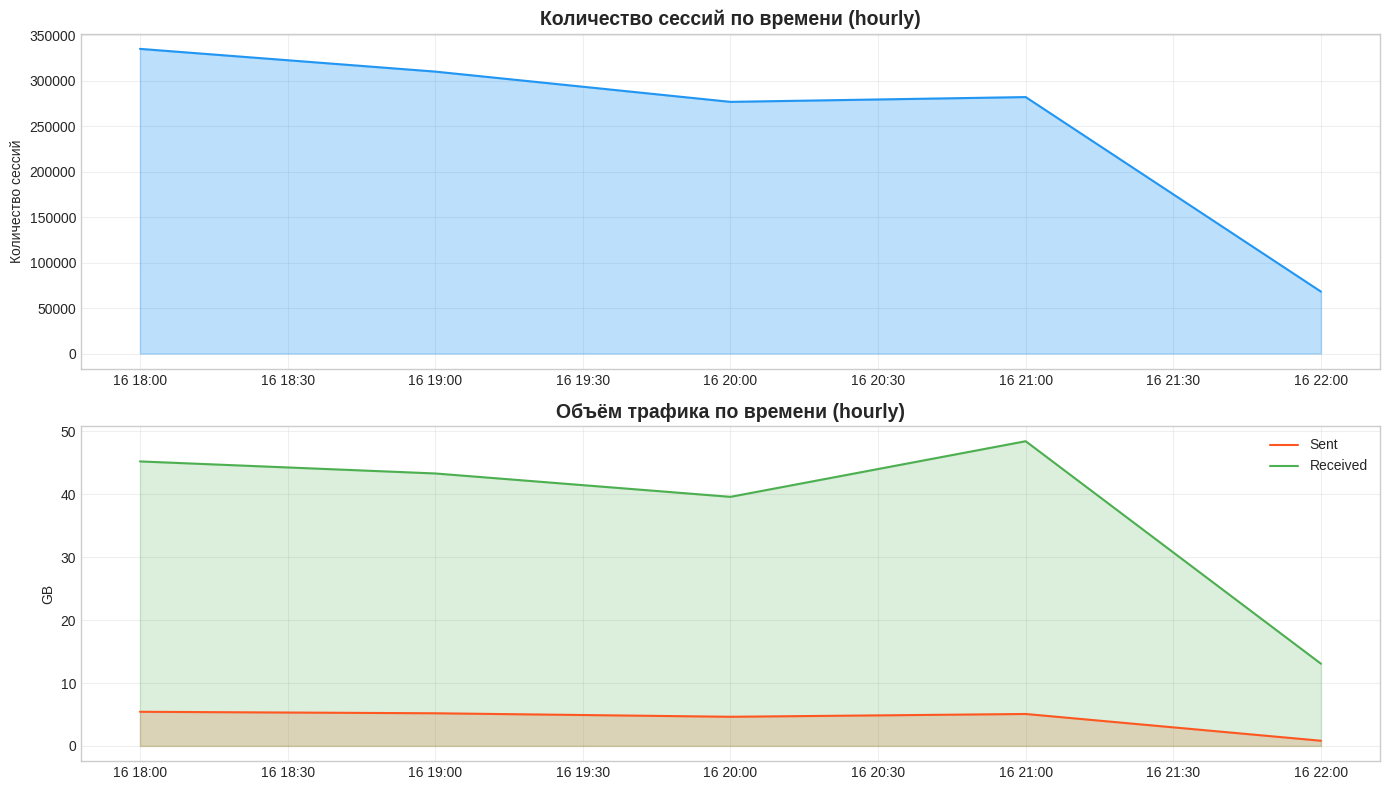

✓ Сохранён: reports/eda/01_traffic_timeline.png


In [6]:
df = pd.read_csv('data/data_tmp/feature_eng_done.csv')
eda.plot_traffic_timeline(df)

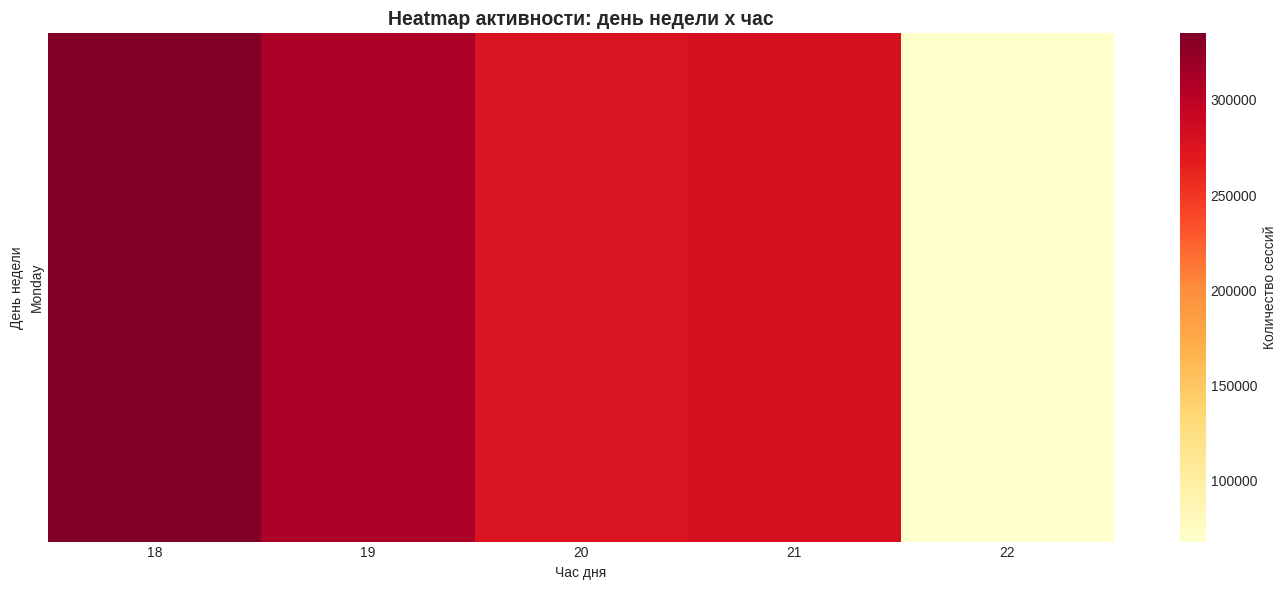

✓ Сохранён: reports/eda/02_activity_heatmap.png


In [7]:
eda.plot_activity_heatmap(df)

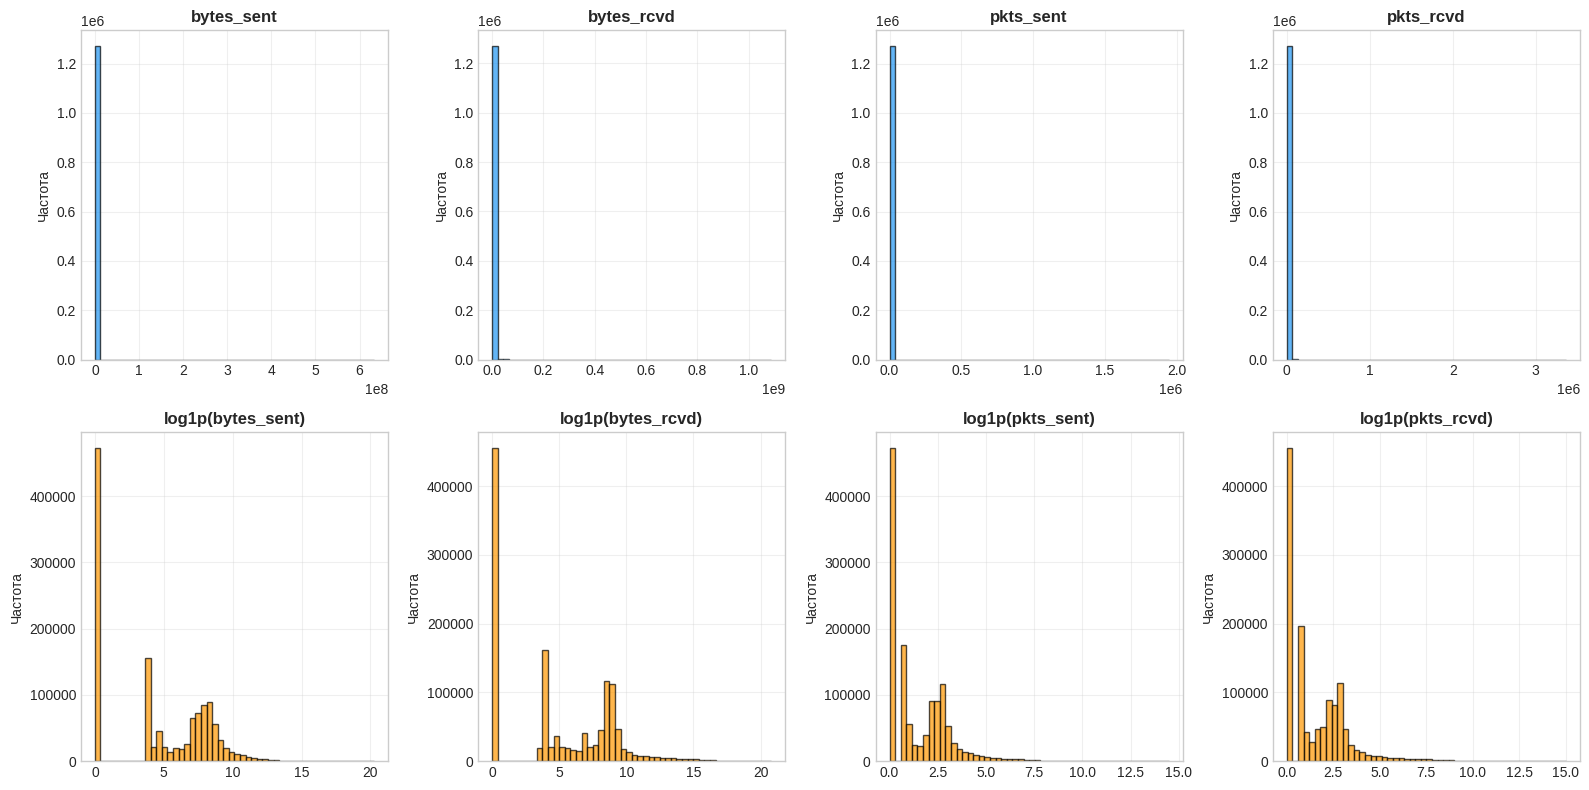

✓ Сохранён: reports/eda/03_feature_distributions.png


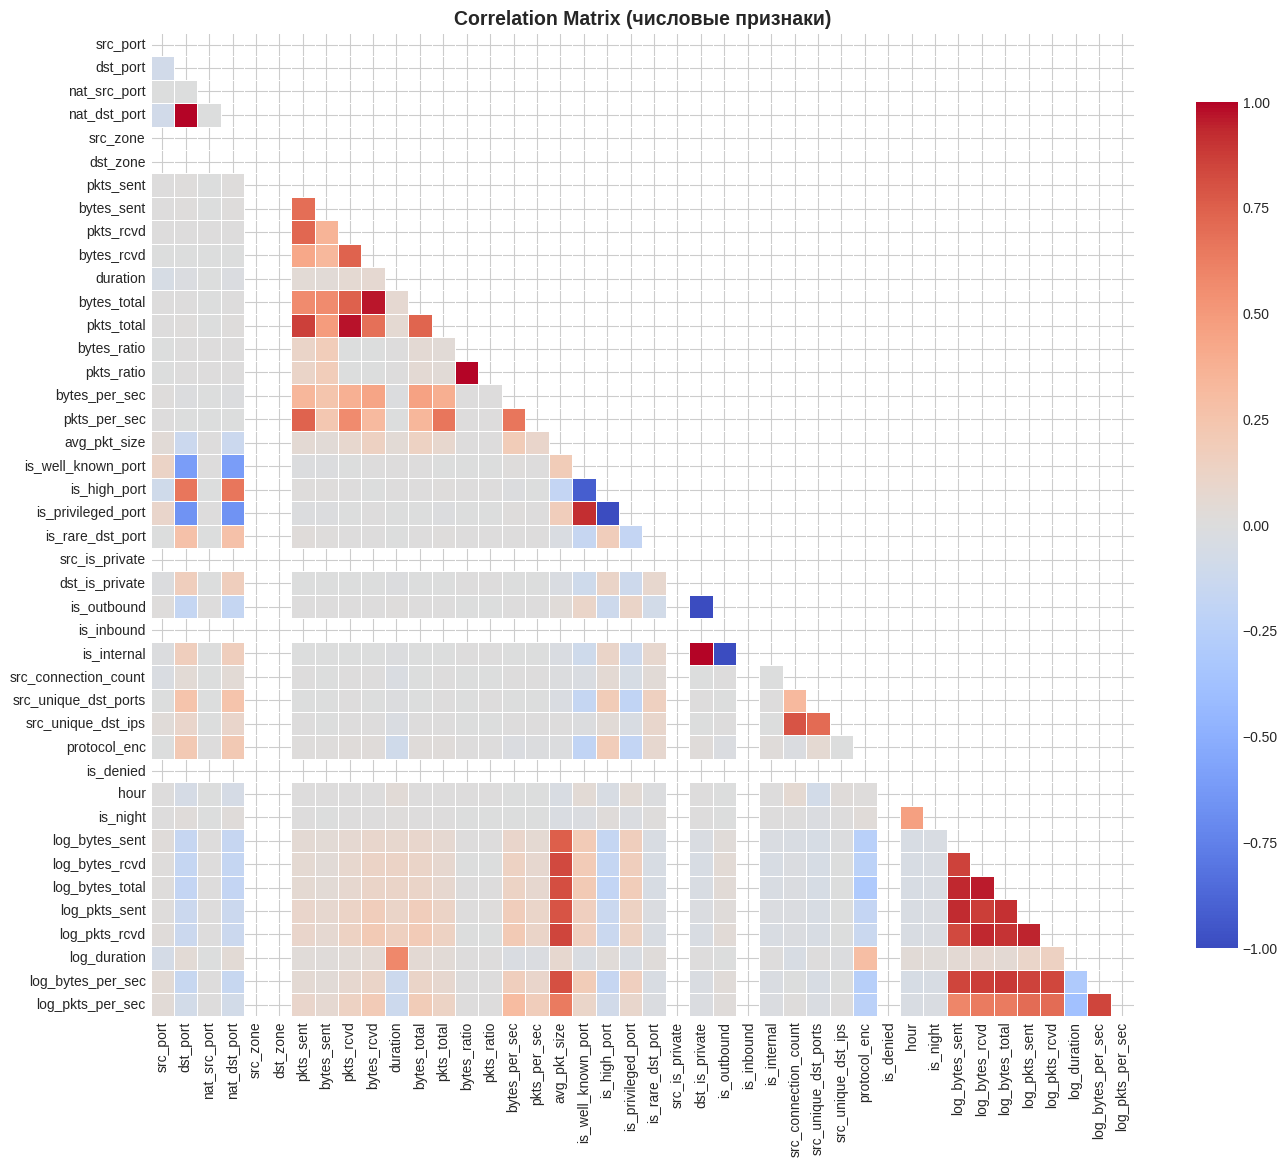

✓ Сохранён: reports/eda/04_correlation_heatmap.png


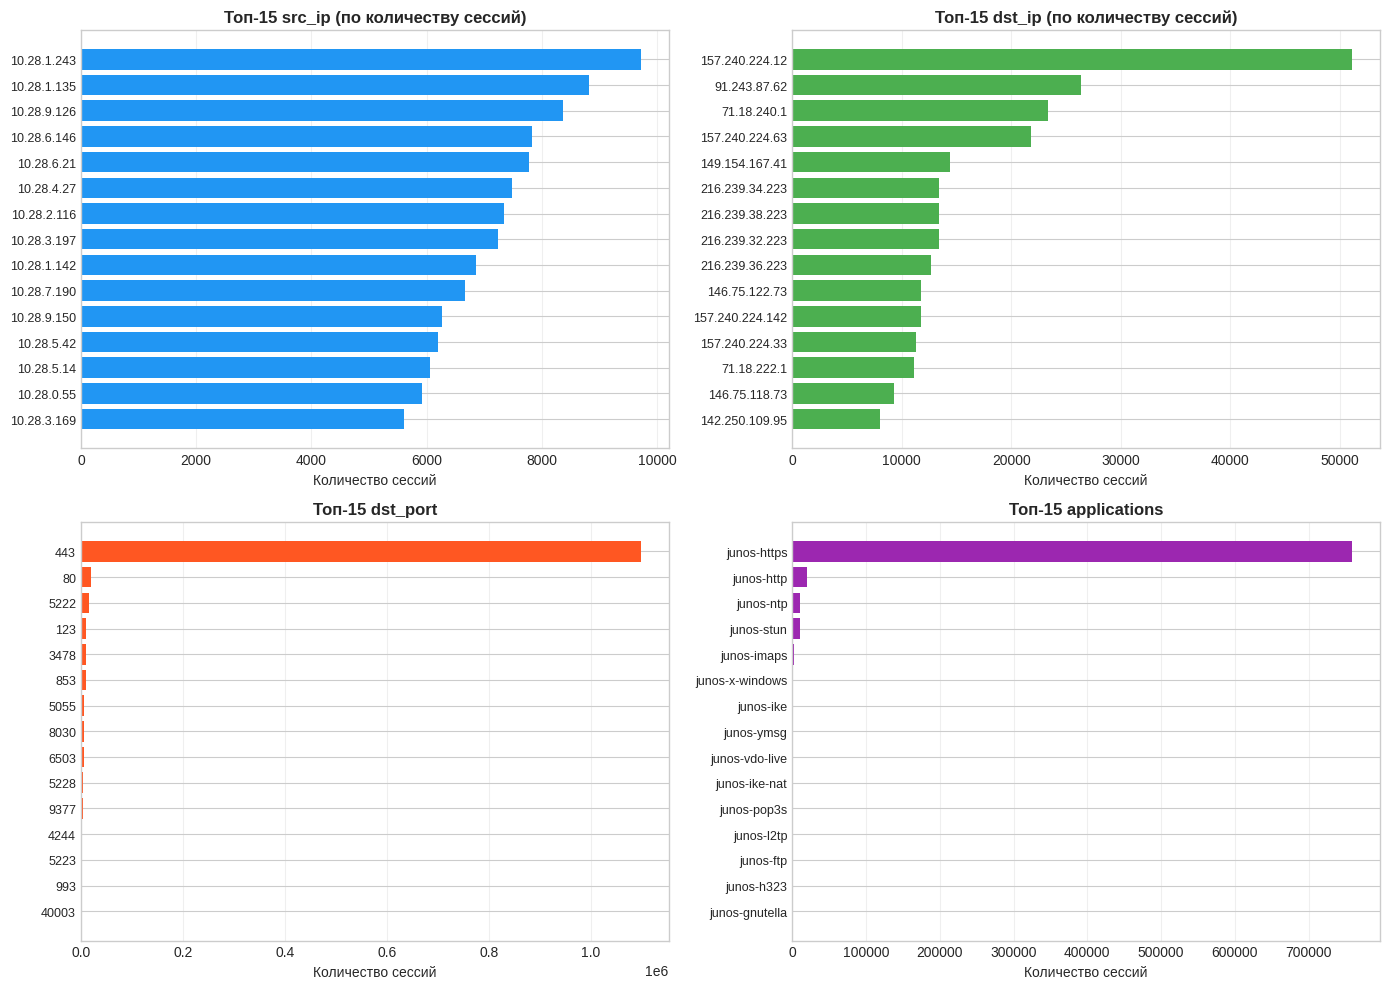

✓ Сохранён: reports/eda/05_top_ips_ports_apps.png


In [8]:
eda.plot_feature_distributions(df)
eda.plot_correlation_heatmap(df)
eda.plot_top_ips_and_ports(df)

## 5. Подготовка матрицы признаков

In [9]:
df_features = pd.read_csv('data/data_tmp/feature_eng_done.csv')
print(df_features.shape)
X, scaler, feature_names = prepare_features(df_features, fit=True)

print(f"Матрица X: {X.shape}")

# Сохраняем scaler для inference
with open("data/data_tmp/pickle_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Сохраняем данные для будущего обучения моделей
np.save("data/data_tmp/X.npy", X)

print('\nСписок финальных признаков используемых для обучения модели:')
for feature in feature_names:
    print(feature)

(1271439, 58)
Признаков для модели: 30
Матрица X: (1271439, 30)

Список финальных признаков используемых для обучения модели:
log_bytes_sent
log_bytes_rcvd
log_bytes_total
log_pkts_sent
log_pkts_rcvd
log_duration
log_bytes_per_sec
log_pkts_per_sec
bytes_ratio
pkts_ratio
avg_pkt_size
dst_port
src_port
is_well_known_port
is_high_port
is_privileged_port
is_rare_dst_port
src_is_private
dst_is_private
is_outbound
is_inbound
is_internal
src_connection_count
src_unique_dst_ports
src_unique_dst_ips
protocol_enc
is_denied
hour
day_of_week
is_night


## 6. Обучение моделей

In [10]:
# Загрузка тренеровачных данных для последующего обучения
X = np.load("data/data_tmp/X.npy")

### 6.1 Isolation Forest

In [11]:
# Обучение IsolationForest
isolation_forest = IsolationForestDetector(contamination=0.001)
isolation_forest.fit(X)

# Сохраняем модель
isolation_forest.save('models/isolation_forest.pkl')

Обучение Isolation Forest на 1271439 записях...
Модель сохранена: models/isolation_forest.pkl


In [12]:
# Использование модели IsolationForest для предсказаний

print('Загрузить предобработанные данные')
Y = np.load("data/data_tmp/X.npy")

print('Загрузить фаил уже обученной модели')
with open("models/isolation_forest.pkl", "rb") as f:
   isolation_forest_model = pickle.load(f)

y_pred = isolation_forest_model.predict(Y)
y_pred = np.where(y_pred == -1, 1, 0)
print('===================== Результаты предсказаний ======================')
values, counts = np.unique(y_pred, return_counts=True)
print('1 - аномалия, 0 - норма')
print(values)
print(counts)

print('=======================================')
scores = -isolation_forest_model.score_samples(Y)

print("Isolation Forest score is ", scores)
print("min:", scores.min())
print("max:", scores.max())

df_features = pd.read_csv('data/data_tmp/feature_eng_done.csv')

# Экспорт от Isolation Forest
export_top_anomalies(
        df_features, y_pred,
        scores,
        "Isolation_Forest", top_n=100,
        output_dir = 'anomalies_results/'
    )

Загрузить предобработанные данные
Загрузить фаил уже обученной модели
===================== Результаты предсказаний ======================
1 - аномалия, 0 - норма
[0 1]
[1270183    1256]
Isolation Forest score is  [0.63238409 0.4276309  0.53972582 ... 0.56563194 0.5677056  0.45883575]
min: 0.3722874426457128
max: 0.7562225960459638
✓ Экспортировано 100 аномалий: anomalies_results/anomalies_isolation_forest_top100.csv
  Для ручной проверки: заполните колонки 'manual_label' и 'notes'


'anomalies_results/anomalies_isolation_forest_top100.csv'

### 6.2 AUTOENCODER (Neural Network)

In [13]:
# Обучение AutoencoderDetector (Neural Network)

autoencoder_model = AutoencoderDetector()
autoencoder_model.fit(X)

# Сохраняем модель
autoencoder_model.save('models/autoencoder.pkl')

Обучение Autoencoder на 1271439 записях...
Epoch 1/50
4470/4470 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.2443 - val_loss: 0.7450
Epoch 2/50
4470/4470 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.1886 - val_loss: 0.8690
Epoch 3/50
4470/4470 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.1707 - val_loss: 0.9032
Epoch 4/50
4470/4470 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.1668 - val_loss: 0.9467
Epoch 5/50
4470/4470 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.1615 - val_loss: 0.9035
Epoch 6/50
4470/4470 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.1609 - val_loss: 0.8569
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Порог аномалии (p95): 1.0910
Autoencoder сохранён: models/autoencoder_keras.keras, мета: models/autoencoder.pkl


In [14]:
# Использование модели AutoencoderDetector для предсказаний

print('Загрузить предобработанные данные')
Y = np.load("data/data_tmp/X.npy")

print('Загрузить фаил уже обученной модели')
autoencoder_model = AutoencoderDetector()
autoencoder_model.load("models/autoencoder.pkl")

print(type(autoencoder_model))

y_pred = autoencoder_model.predict(Y)
scores = autoencoder_model.score(Y)

print("AutoencoderDetector score is ", scores)
print("min:", scores.min())
print("max:", scores.max())

df_features = pd.read_csv('data/data_tmp/feature_eng_done.csv')

# Экспорт от AUTOENCODER
export_top_anomalies(
        df_features, y_pred,
        scores,
        "AutoencoderDetector", top_n=100,
        output_dir = 'anomalies_results/'
    )

Загрузить предобработанные данные
Загрузить фаил уже обученной модели
<class 'modules.models.AutoencoderDetector'>
AutoencoderDetector score is  [0.28632994 0.0270532  0.06624135 ... 1.12112782 1.12129499 1.65590156]
min: 0.001593301471522877
max: 91436.68699374766
✓ Экспортировано 100 аномалий: anomalies_results/anomalies_autoencoderdetector_top100.csv
  Для ручной проверки: заполните колонки 'manual_label' и 'notes'


'anomalies_results/anomalies_autoencoderdetector_top100.csv'

### 6.3 LOFDetector (Neural Network)

In [35]:
# Обучение LOFDetector (Neural Network)

lof_model = LOFDetector()
lof_model.fit(X)

# Сохраняем модель
lof_model.save('models/lofmodel.pkl')

Обучение Local Outlier Factor на 1271439 записях...


In [36]:
# Использование модели LOFDetector для предсказаний

print('Загрузить предобработанные данные')
Y = np.load("data/data_tmp/X.npy")

print('Загрузить фаил уже обученной модели')
lof_model = LOFDetector()
lof_model.load("models/lofmodel.pkl")

y_pred = lof_model.predict(Y)
scores = lof_model.score(Y)

print("LOFDetector score is ", scores)
print("min:", scores.min())
print("max:", scores.max())

df_features = pd.read_csv('data/data_tmp/feature_eng_done.csv')

# Экспорт от LOFDetector
export_top_anomalies(
        df_features, y_pred,
        scores,
        "LOFDetector", top_n=100,
        output_dir = 'anomalies_results/'
    )

Загрузить предобработанные данные
Загрузить фаил уже обученной модели
LOFDetector score is  [1.08941576 1.22522743 1.08912896 ... 0.9912005  0.9912005  1.0988101 ]
min: 0.847118551126891
max: 6159243547.499156
✓ Экспортировано 100 аномалий: anomalies_results/anomalies_lofdetector_top100.csv
  Для ручной проверки: заполните колонки 'manual_label' и 'notes'


'anomalies_results/anomalies_lofdetector_top100.csv'

### 6.4 OneClassSVMDetector

In [29]:
# Обучение OneClassSVMDetector

oneclasssvm_model = OneClassSVMDetector()
oneclasssvm_model.fit(X)

# Сохраняем модель
oneclasssvm_model.save('models/oneclasssvm_model.pkl')

Обучение One-Class SVM на 1271439 записях...
Датасет большой, обучаем на подвыборке: 50,000 записей


In [30]:
# Использование модели OneClassSVMDetector для предсказаний

print('Загрузить предобработанные данные')
Y = np.load("data/data_tmp/X.npy")

print('Загрузить фаил уже обученной модели')
oneclasssvm_model = OneClassSVMDetector()
oneclasssvm_model.load("models/oneclasssvm_model.pkl")

y_pred = lof_model.predict(Y)
scores = lof_model.score(Y)

print("OneClassSVMDetector score is ", scores)
print("min:", scores.min())
print("max:", scores.max())

df_features = pd.read_csv('data/data_tmp/feature_eng_done.csv')

# Экспорт от LOFDetector
export_top_anomalies(
        df_features, y_pred,
        scores,
        "OneClassSVMDetector", top_n=100,
        output_dir = 'anomalies_results/'
    )

Загрузить предобработанные данные
Загрузить фаил уже обученной модели
OneClassSVMDetector score is  [1.08941576 1.22522743 1.08912896 ... 0.9912005  0.9912005  1.0988101 ]
min: 0.847118551126891
max: 6159243547.499156
✓ Экспортировано 100 аномалий: anomalies_results/anomalies_oneclasssvmdetector_top100.csv
  Для ручной проверки: заполните колонки 'manual_label' и 'notes'


'anomalies_results/anomalies_oneclasssvmdetector_top100.csv'

### 7. Результаты

In [31]:
print('Isolation Forest top 10 result')
pd.read_csv('anomalies_results/anomalies_isolation_forest_top100.csv').head(n=10)

Isolation Forest top 10 result


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,application,policy,bytes_sent,bytes_rcvd,pkts_sent,pkts_rcvd,duration,action,anomaly_score,manual_label,notes
0,2026-02-16 22:10:19,10.28.0.90,192.168.100.72,62667,59124,UDP,NaN,internet_offload2,9600,0,75,0,59.0,close,0.756223,NaN,NaN
1,2026-02-16 22:11:56,10.28.4.233,185.125.50.18,58799,57998,UDP,NaN,internet_offload2,3288903,56575026,35276,57153,4195.0,close,0.753337,NaN,NaN
2,2026-02-16 22:03:52,10.28.8.87,128.116.5.33,45543,50074,UDP,NaN,internet_offload2,3105910,0,5451,0,100.0,close,0.748976,NaN,NaN
3,2026-02-16 22:03:32,10.28.0.90,192.168.200.37,55374,60202,UDP,NaN,internet_offload2,9600,0,75,0,73.0,close,0.747865,NaN,NaN
4,2026-02-16 22:10:10,10.28.0.90,192.168.0.101,57520,39613,UDP,NaN,internet_offload2,11532,0,93,0,70.0,close,0.747106,NaN,NaN
5,2026-02-16 21:39:01,10.28.2.116,104.166.191.54,40621,10011,UDP,NaN,internet_offload2,1156640,1754866,17598,22352,729.0,close,0.743907,NaN,NaN
6,2026-02-16 22:03:32,10.28.0.90,192.168.200.38,55372,55281,UDP,NaN,internet_offload2,9600,0,75,0,73.0,close,0.743865,NaN,NaN
7,2026-02-16 21:18:16,10.28.2.116,66.253.15.208,37464,10013,UDP,NaN,internet_offload2,1054626,1618655,15722,20817,679.0,close,0.743655,NaN,NaN
8,2026-02-16 20:40:00,10.28.4.233,192.168.37.148,59945,58578,UDP,NaN,internet_offload2,14592,0,114,0,74.0,close,0.741249,NaN,NaN
9,2026-02-16 20:21:22,10.28.2.116,66.253.15.217,38449,10011,UDP,NaN,internet_offload2,885234,1284168,13258,16763,600.0,close,0.740893,NaN,NaN


In [32]:
print('AUTOENCODER top 10 result')
pd.read_csv('anomalies_results/anomalies_autoencoderdetector_top100.csv').head(n=10)

AUTOENCODER top 10 result


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,application,policy,bytes_sent,bytes_rcvd,pkts_sent,pkts_rcvd,duration,action,anomaly_score,manual_label,notes
0,2026-02-16 20:36:25,10.28.2.194,95.135.109.32,37954,57312,UDP,NaN,internet_offload2,257892995,0,318585,0,1506.0,close,91436.686994,NaN,NaN
1,2026-02-16 22:03:52,10.28.8.87,128.116.5.33,45543,50074,UDP,NaN,internet_offload2,3105910,0,5451,0,100.0,close,21.219800,NaN,NaN
2,2026-02-16 21:44:19,10.28.8.87,128.116.31.33,48401,64901,UDP,NaN,internet_offload2,1740338,0,4789,0,113.0,close,14.469988,NaN,NaN
3,2026-02-16 18:42:01,10.28.8.42,89.45.2.225,53959,443,UDP,NaN,internet_offload2,2504479,76,9547,1,1961.0,close,11.531451,NaN,NaN
4,2026-02-16 21:50:44,10.28.8.87,128.116.44.33,40824,58878,UDP,NaN,internet_offload2,1804625,0,3408,0,77.0,close,8.728725,NaN,NaN
5,2026-02-16 20:52:32,10.28.1.212,192.168.8.106,64088,57316,TCP,NaN,internet_offload2,0,0,0,0,18.0,close,7.692790,NaN,NaN
6,2026-02-16 22:01:21,10.28.9.18,192.168.254.254,3233,69,UDP,junos-tftp,internet_offload2,270,0,3,0,62.0,close,7.565333,NaN,NaN
7,2026-02-16 20:36:36,10.28.1.231,192.168.100.2,64847,51921,TCP,NaN,internet_offload2,0,0,0,0,18.0,close,7.498676,NaN,NaN
8,2026-02-16 19:48:24,10.28.0.153,192.168.1.6,64568,50785,UDP,NaN,internet_offload2,0,0,0,0,60.0,close,7.473162,NaN,NaN
9,2026-02-16 19:00:21,10.28.8.219,192.168.1.2,60926,61668,UDP,NaN,internet_offload2,396,0,3,0,68.0,close,7.440076,NaN,NaN


In [37]:
print('LOFDetector  top 10 result')
pd.read_csv('anomalies_results/anomalies_lofdetector_top100.csv').head(n=10)

LOFDetector  top 10 result


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,application,policy,bytes_sent,bytes_rcvd,pkts_sent,pkts_rcvd,duration,action,anomaly_score,manual_label,notes
0,2026-02-16 19:30:29,10.28.0.69,37.225.30.7,57798,24015,UDP,NaN,internet_offload2,0,0,0,0,60.0,close,6.159244e+09,NaN,NaN
1,2026-02-16 19:30:29,10.28.0.69,37.225.30.7,63174,24015,UDP,NaN,internet_offload2,0,0,0,0,60.0,close,5.706686e+09,NaN,NaN
2,2026-02-16 19:31:41,10.28.0.69,37.225.30.7,63174,24015,UDP,NaN,internet_offload2,0,0,0,0,59.0,close,5.706641e+09,NaN,NaN
3,2026-02-16 19:31:39,10.28.0.69,37.225.30.7,57798,24015,UDP,NaN,internet_offload2,0,0,0,0,58.0,close,3.316589e+09,NaN,NaN
4,2026-02-16 18:50:14,10.28.3.124,45.150.174.190,53600,10572,UDP,NaN,internet_offload2,0,0,0,0,58.0,close,2.998010e+09,NaN,NaN
5,2026-02-16 20:49:17,10.28.0.171,57.144.111.132,56832,3478,UDP,junos-stun,internet_offload2,0,0,0,0,63.0,close,2.729877e+09,NaN,NaN
6,2026-02-16 20:47:13,10.28.0.171,157.240.224.19,57249,3478,UDP,junos-stun,internet_offload2,0,0,0,0,60.0,close,2.727929e+09,NaN,NaN
7,2026-02-16 20:48:13,10.28.0.171,157.240.224.19,57249,3478,UDP,junos-stun,internet_offload2,0,0,0,0,60.0,close,2.727929e+09,NaN,NaN
8,2026-02-16 20:49:13,10.28.0.171,157.240.224.19,57249,3478,UDP,junos-stun,internet_offload2,0,0,0,0,60.0,close,2.727929e+09,NaN,NaN
9,2026-02-16 20:47:13,10.28.0.171,57.144.111.132,56832,3478,UDP,junos-stun,internet_offload2,0,0,0,0,60.0,close,2.727356e+09,NaN,NaN
